***Link dataset***
- https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- https://www.kaggle.com/datasets/zubairmustafa/spam-and-ham-classification-balanced-dataset
- https://www.kaggle.com/datasets/vinit119/sms-scam-detection-dataset-merged

# Case Study 6 – Phân loại tin nhắn spam / không spam

**Mục tiêu:**
- Thu thập dữ liệu từ 3 bộ dataset trên Kaggle (SMS / email spam).
- Tiền xử lý văn bản (text preprocessing) và chuyển sang dạng số bằng **Embedding**.
- Xây dựng mô hình **LSTM (>= 7 layer)** để phân loại spam / ham.
- Trực quan hóa:
  - Phân bố số lượng spam vs ham.
  - Quá trình train (loss, val_loss, accuracy, val_accuracy).
  - Ma trận nhầm lẫn (confusion matrix) trên tập test.

**Nguồn dataset (Kaggle):**
1. SMS Spam Collection (UCI).
2. Spam and Ham classification Balanced Dataset.
3. SMS Scam detection dataset merged.

Toàn bộ code được chú thích bằng tiếng Việt để dùng cho báo cáo & notebook.


***Cell [2]. [Import thư viện & đặt seed]***

In [1]:
#B22DCCN476 - Đỗ Ngọc Lâm 
#Cell [2]. [Import thư viện & đặt seed]

import os
import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Đặt seed cố định cho reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## Đọc & gộp 3 dataset Kaggle

Trong phần này, ta sẽ:
- Đọc 3 file CSV tải từ Kaggle.
- Chuẩn hóa lại cột:
  - Cột văn bản: `text`
  - Cột nhãn: `label` (0 = ham/not spam, 1 = spam)
- Gộp 3 dataset lại thành một DataFrame duy nhất để train mô hình chung.

**Lưu ý:**  
- Bộ UCI `spam.csv` thường có cột `v1` (nhãn ham/spam) và `v2` (nội dung).
- Hai bộ còn lại thường dùng `label` và `text`.


In [2]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [4]. [Đọc & chuẩn hóa 3 dataset]

def safe_read_csv(path):
    """
    Đọc CSV với auto-fallback encoding.
    Ưu tiên latin-1 (phổ biến kaggle) -> cp1252 -> utf-8
    """
    try:
        return pd.read_csv(path, encoding="latin-1", low_memory=False)
    except:
        try:
            return pd.read_csv(path, encoding="cp1252", low_memory=False)
        except:
            return pd.read_csv(path, encoding="utf-8", low_memory=False)


def load_and_standardize_uci(path):
    df = safe_read_csv(path)

    if {'v1', 'v2'}.issubset(df.columns):
        df = df[['v1', 'v2']]
        df.columns = ['label_raw', 'text']
    else:
        df = df.iloc[:, :2]
        df.columns = ['label_raw', 'text']

    df['label'] = df['label_raw'].astype(str).str.lower().map({
        'ham': 0,
        'spam': 1
    })

    df = df.dropna(subset=['text', 'label'])
    return df[['text', 'label']]


def load_and_standardize_generic(path):
    df = safe_read_csv(path)

    # Tìm cột TEXT
    text_candidates = ['text', 'message', 'sms', 'content']
    text_col = next(col for col in text_candidates if col in df.columns)

    # Tìm cột LABEL
    label_candidates = ['label', 'target', 'category', 'class']
    label_col = next(col for col in label_candidates if col in df.columns)

    df = df[[text_col, label_col]]
    df.columns = ['text', 'label_raw']

    if df['label_raw'].dtype == 'O':
        df['label'] = df['label_raw'].astype(str).str.lower().map({
            'ham': 0,
            'spam': 1
        })
    else:
        df['label'] = df['label_raw'].astype(int)

    df = df.dropna(subset=['text', 'label'])
    df = df[df['label'].isin([0,1])]

    return df[['text','label']]


# ===== ĐỌC 3 DATASET ===================================================

path_uci      = "data/spam.csv"
path_balanced = "data/spam_and_ham_classification.csv"
path_scam     = "data/sms_scam_detection_dataset_merged_with_lang.csv"

df_uci      = load_and_standardize_uci(path_uci)
df_balanced = load_and_standardize_generic(path_balanced)
df_scam     = load_and_standardize_generic(path_scam)

print("UCI:", df_uci.shape)
print("Balanced:", df_balanced.shape)
print("Scam:", df_scam.shape)

# ===== GỘP DATA ========================================================

df_all = pd.concat([df_uci, df_balanced, df_scam], ignore_index=True)
df_all = df_all.drop_duplicates(subset=['text'])
df_all = df_all.reset_index(drop=True)

print("\nTỔNG dataset:")
print(df_all.shape)
df_all.head()


UCI: (5572, 2)
Balanced: (9989, 2)
Scam: (138812, 2)

TỔNG dataset:
(149149, 2)


,text,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


## Tiền xử lý văn bản (text preprocessing)

Các bước xử lý cơ bản:
1. Chuyển toàn bộ về **chữ thường (lowercase)**.
2. Loại bỏ:
   - URL (http, https, www).
   - Số (digits).
   - Dấu câu (punctuation).
   - Nhiều khoảng trắng liên tiếp.
3. (Tuỳ chọn) Có thể thêm stopwords, stemming, lemmatization – nhưng để đơn giản ta tạm thời không dùng.

Kết quả được lưu vào cột mới `clean_text`.


In [3]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [6]. [Tiền xử lý văn bản]

url_pattern = re.compile(r'https?://\S+|www\.\S+')
html_pattern = re.compile(r'<.*?>')

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = url_pattern.sub(' ', text)
    text = html_pattern.sub(' ', text)
    text = re.sub(r'\d+', ' ', text)  # bỏ số
    text = text.translate(str.maketrans('', '', string.punctuation))  # bỏ dấu câu
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_all['clean_text'] = df_all['text'].apply(clean_text)

df_all[['text', 'clean_text', 'label']].head()


,text,clean_text,label
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...,0
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...,1
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say,0
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...,0


## Trực quan hóa phân bố nhãn (spam vs ham)

Trước khi train model, ta cần:
- Xem dataset có **cân bằng hay lệch nhãn**.
- Nếu lệch quá nhiều có thể cân nhắc:
  - Oversampling / Undersampling
  - Class weights

Ở đây ta vẽ **biểu đồ bar** thể hiện số lượng spam / ham trong toàn bộ dữ liệu đã gộp.


label
0    83839
1    65310
Name: count, dtype: int64


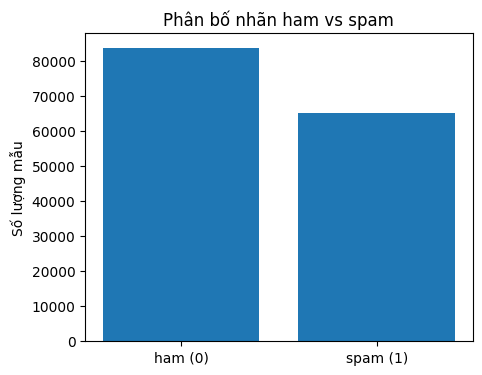

In [4]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [8]. [Vẽ phân bố spam/ham]

label_counts = df_all['label'].value_counts().sort_index()
print(label_counts)

plt.figure(figsize=(5,4))
plt.bar(['ham (0)', 'spam (1)'], label_counts.values)
plt.title("Phân bố nhãn ham vs spam")
plt.ylabel("Số lượng mẫu")
plt.show()


## Tách train/validation/test & Tokenizer

Các bước:
1. Tách dữ liệu thành:
   - Train: 70%
   - Validation: 15%
   - Test: 15%
2. Dùng `Tokenizer` của Keras để:
   - Xây dựng từ điển (vocabulary).
   - Chuyển câu `clean_text` thành chuỗi các chỉ số (sequence of integers).
3. Dùng `pad_sequences` để:
   - Đưa tất cả các sequence về cùng chiều dài `MAX_LEN`.

Các biến chính:
- `MAX_WORDS`: số lượng từ tối đa trong vocab.
- `MAX_LEN`: chiều dài chuỗi tối đa (padding/truncating).


In [5]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [10]. [Tách dữ liệu & Tokenizer]

MAX_WORDS = 20000
MAX_LEN = 100

X = df_all['clean_text'].values
y = df_all['label'].values

# Train (70%) + temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

# Validation (15%) + Test (15%) từ temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))

# Tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convert text -> sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad shape:", X_val_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)


Train size: 104404
Val size: 22372
Test size: 22373
X_train_pad shape: (104404, 100)
X_val_pad shape: (22372, 100)
X_test_pad shape: (22373, 100)


## Xây dựng mô hình LSTM (KHÔNG Dropout, ≥ 7 learnable layers)

Tiêu chí:
- Không sử dụng Dropout trong phiên bản đầu tiên.
- Chỉ tính các layer học được tham số (Embedding, LSTM, Dense, ...).
- Kiến trúc đề xuất:

1. **Embedding** (vocab_size = MAX_WORDS, output_dim = 128)
2. **LSTM(128, return_sequences=True)**
3. **LSTM(64, return_sequences=True)**
4. **LSTM(32, return_sequences=False)**
5. **Dense(128, activation='relu')**
6. **Dense(64, activation='relu')**
7. **Dense(32, activation='relu')**
8. **Dense(1, activation='sigmoid')**  ← output layer

Như vậy ta có **8 learnable layers** (thỏa điều kiện ≥ 7, KHÔNG dùng Dropout).


In [7]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [12]. [Xây dựng mô hình LSTM ≥ 7 learnable layers, không Dropout]

EMBED_DIM = 128

model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, input_length=MAX_LEN),  # 1
    LSTM(128, return_sequences=True),                                            # 2
    LSTM(64,  return_sequences=True),                                            # 3
    LSTM(32,  return_sequences=False),                                           # 4
    Dense(128, activation='relu'),                                               # 5
    Dense(64,  activation='relu'),                                               # 6
    Dense(32,  activation='relu'),                                               # 7
    Dense(1,   activation='sigmoid')                                             # 8 (output)
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Compile & Train mô hình

- Loss: `binary_crossentropy`.
- Optimizer: `adam`.
- Metrics: `accuracy`.

Dùng callback:
- `EarlyStopping`: dừng sớm khi `val_loss` không giảm nữa.
- `ModelCheckpoint`: lưu model tốt nhất (val_loss nhỏ nhất).

Sau khi train, ta sẽ:
- Vẽ đường loss / val_loss.
- Vẽ đường accuracy / val_accuracy.


In [9]:
#B22DCCN476 - Đỗ ngọc Lâm 
#Cell [14]. [Compile & train model LSTM]

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

EPOCHS = 10
BATCH_SIZE = 128

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint("best_lstm_spam_no_dropout.h5", monitor='val_loss', save_best_only=True)
]

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.5673 - loss: 0.6838

816/816 ━━━━━━━━━━━━━━━━━━━━ 176s 211ms/step - accuracy: 0.5665 - loss: 0.6841 - val_accuracy: 0.5621 - val_loss: 0.6859
Epoch 2/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.5617 - loss: 0.6855

816/816 ━━━━━━━━━━━━━━━━━━━━ 170s 208ms/step - accuracy: 0.5621 - loss: 0.6853 - val_accuracy: 0.5621 - val_loss: 0.6847
Epoch 3/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 171s 209ms/step - accuracy: 0.5818 - loss: 0.6770 - val_accuracy: 0.5669 - val_loss: 0.6847
Epoch 4/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.5836 - loss: 0.6693

816/816 ━━━━━━━━━━━━━━━━━━━━ 158s 194ms/step - accuracy: 0.6228 - loss: 0.6330 - val_accuracy: 0.7270 - val_loss: 0.5354
Epoch 5/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.7619 - loss: 0.4824

816/816 ━━━━━━━━━━━━━━━━━━━━ 159s 195ms/step - accuracy: 0.7893 - loss: 0.4382 - val_accuracy: 0.8035 - val_loss: 0.4153
Epoch 6/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 157s 193ms/step - accuracy: 0.8451 - loss: 0.3381 - val_accuracy: 0.8137 - val_loss: 0.4211
Epoch 7/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 158s 193ms/step - accuracy: 0.8720 - loss: 0.2830 - val_accuracy: 0.8100 - val_loss: 0.4535
Epoch 8/10
816/816 ━━━━━━━━━━━━━━━━━━━━ 159s 194ms/step - accuracy: 0.8946 - loss: 0.2375 - val_accuracy: 0.8123 - val_loss: 0.4817


## Trực quan hóa quá trình huấn luyện

Dùng `history.history` để vẽ:
- `loss` vs `val_loss`
- `accuracy` vs `val_accuracy`

Mục đích:
- Kiểm tra xem mô hình có overfit không.
- Đánh giá tốc độ hội tụ, chất lượng training.


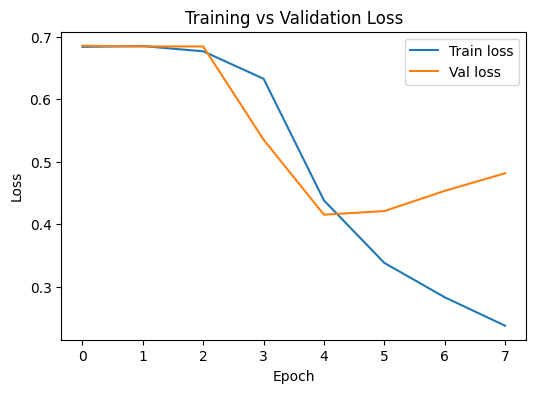

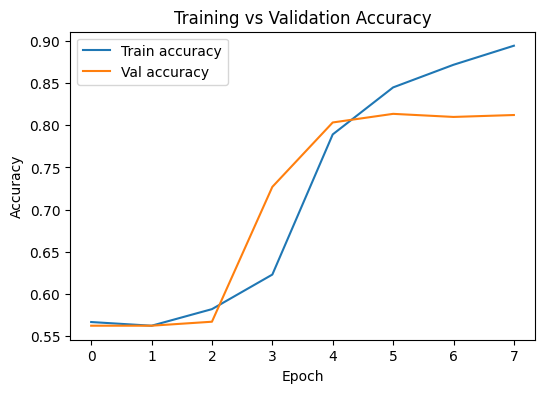

In [10]:
#B22DCCN476 - Đỗ Ngọc Lâm 
#Cell [16]. [Vẽ loss & accuracy]

# Loss
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'],     label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'],     label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


## Đánh giá trên tập test & ma trận nhầm lẫn

Các bước:
1. Dùng `model.evaluate()` trên `X_test_pad`, `y_test` để lấy test loss + test accuracy.
2. Dùng `model.predict()` để lấy xác suất dự đoán → áp ngưỡng 0.5 thành 0/1.
3. Tính `confusion_matrix` và vẽ bằng `ConfusionMatrixDisplay`.
4. In `classification_report` (precision, recall, f1-score).

Phần này rất quan trọng để phân tích mô hình trong báo cáo.


Test Loss: 0.4075
Test Accuracy: 0.8062
700/700 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step


<Figure size 500x400 with 0 Axes>

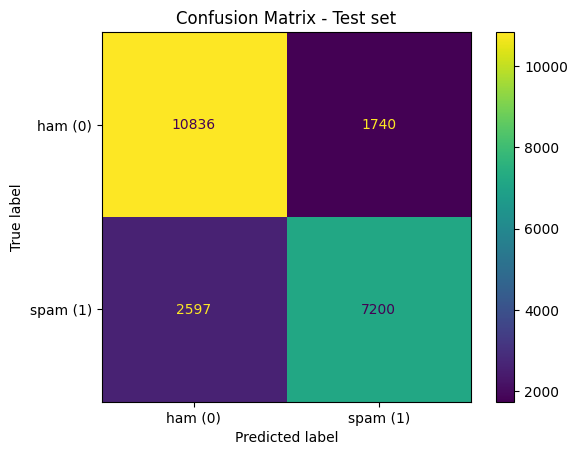

Classification report:
              precision    recall  f1-score   support

         ham       0.81      0.86      0.83     12576
        spam       0.81      0.73      0.77      9797

    accuracy                           0.81     22373
   macro avg       0.81      0.80      0.80     22373
weighted avg       0.81      0.81      0.80     22373



In [11]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [18]. [Đánh giá mô hình & vẽ confusion matrix]

# Đánh giá trên test set
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Dự đoán xác suất
y_prob = model.predict(X_test_pad)
y_pred = (y_prob >= 0.5).astype(int).ravel()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham (0)', 'spam (1)'])

plt.figure(figsize=(5, 4))
disp.plot(values_format='d')
plt.title("Confusion Matrix - Test set")
plt.show()

# Classification report
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))


In [12]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [20]. [Xây dựng mô hình LSTM ≥ 7 learnable layers --> sửa overfit]

from tensorflow.keras.regularizers import l2

EMBED_DIM = 128

model_2 = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, input_length=MAX_LEN),   # 1
    LSTM(128, return_sequences=True),                                             # 2
    Dropout(0.2),                                                                 # (không tính layer)
    LSTM(64, return_sequences=True),                                              # 3
    Dropout(0.2),                                                                 # (không tính layer)
    LSTM(32, return_sequences=False),                                             # 4
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),                   # 5
    Dense(64,  activation='relu', kernel_regularizer=l2(1e-4)),                   # 6
    Dense(32,  activation='relu', kernel_regularizer=l2(1e-4)),                   # 7
    Dense(1,   activation='sigmoid')                                              # 8 (output)
])

model_2.summary()


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_8 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
#B22DCCN476 - Đỗ ngọc Lâm 
#Cell [22]. [Compile & train model LSTM 2]

model_2.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

EPOCHS = 20
BATCH_SIZE = 128

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("best_lstm_spam_regularized.h5", monitor='val_loss', save_best_only=True)
]

history_2 = model_2.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.8745 - loss: 0.2801

816/816 ━━━━━━━━━━━━━━━━━━━━ 177s 214ms/step - accuracy: 0.8867 - loss: 0.2565 - val_accuracy: 0.8030 - val_loss: 0.4289
Epoch 2/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 166s 203ms/step - accuracy: 0.9119 - loss: 0.2077 - val_accuracy: 0.7963 - val_loss: 0.5090
Epoch 3/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 164s 202ms/step - accuracy: 0.9281 - loss: 0.1720 - val_accuracy: 0.7922 - val_loss: 0.5303
Epoch 4/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 162s 199ms/step - accuracy: 0.9383 - loss: 0.1493 - val_accuracy: 0.7920 - val_loss: 0.5778
Epoch 5/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 162s 198ms/step - accuracy: 0.9457 - loss: 0.1323 - val_accuracy: 0.7900 - val_loss: 0.6410
Epoch 6/20
816/816 ━━━━━━━━━━━━━━━━━━━━ 161s 198ms/step - accuracy: 0.9530 - loss: 0.1139 - val_accuracy: 0.7896 - val_loss: 0.7517


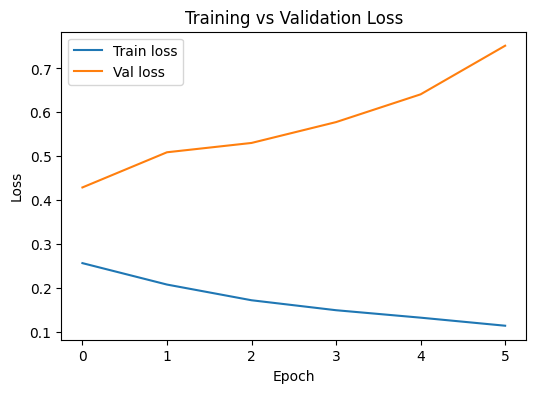

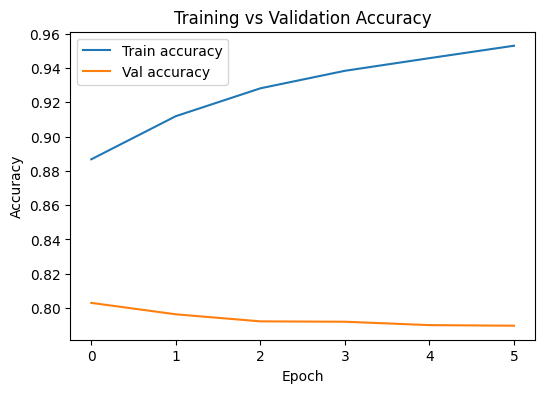

In [18]:
#B22DCCN476 - Đỗ Ngọc Lâm 
#Cell [22]. [Vẽ loss & accuracy]

# Loss
plt.figure(figsize=(6, 4))
plt.plot(history_2.history['loss'],     label='Train loss')
plt.plot(history_2.history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(6, 4))
plt.plot(history_2.history['accuracy'],     label='Train accuracy')
plt.plot(history_2.history['val_accuracy'], label='Val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


Test Loss: 0.4210
Test Accuracy: 0.8092
700/700 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step


<Figure size 500x400 with 0 Axes>

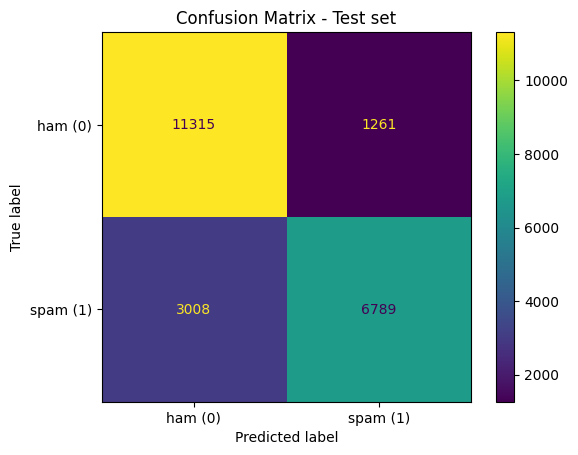

Classification report:
              precision    recall  f1-score   support

         ham       0.79      0.90      0.84     12576
        spam       0.84      0.69      0.76      9797

    accuracy                           0.81     22373
   macro avg       0.82      0.80      0.80     22373
weighted avg       0.81      0.81      0.81     22373



In [19]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [24]. [Đánh giá mô hình & vẽ confusion matrix]

# Đánh giá trên test set
test_loss, test_acc = model_2.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Dự đoán xác suất
y_prob = model_2.predict(X_test_pad)
y_pred = (y_prob >= 0.5).astype(int).ravel()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham (0)', 'spam (1)'])

plt.figure(figsize=(5, 4))
disp.plot(values_format='d')
plt.title("Confusion Matrix - Test set")
plt.show()

# Classification report
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))
